In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
sns.set_theme(style="whitegrid", context="notebook")

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
penguins = sns.load_dataset("penguins")

In [5]:
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [ ]:
#1. Exploración inicial 
#Carga penguins.csv con Pandas. Muestra las primeras 10 filas, las dimensiones del DataFrame, los tipos de 
#datos y la cantidad de valores faltantes por columna. Luego crea penguins_clean eliminando las filas con 
#valores faltantes e indica cuántas filas quedan. 

In [6]:
penguins.shape

(344, 7)

In [7]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [10]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [9]:
penguins.loc[3,:]

species                 Adelie
island               Torgersen
bill_length_mm             NaN
bill_depth_mm              NaN
flipper_length_mm          NaN
body_mass_g                NaN
sex                        NaN
Name: 3, dtype: object

In [11]:
penguins_clean = penguins.dropna().copy()
penguins_clean.shape

(333, 7)

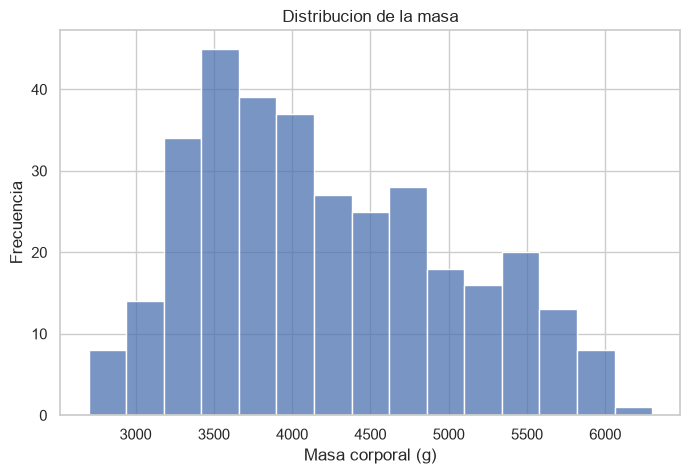

In [15]:
#2. Histograma básico 
#Crea un histplot de body_mass_g con 15 bins. Añade un título y nombres claros a los ejes. 

plt.figure(figsize=(8,5))

sns.histplot(data=penguins_clean, x="body_mass_g", bins=15)
plt.title("Distribucion de la masa")
plt.xlabel("Masa corporal (g)")
plt.ylabel("Frecuencia")
plt.show()

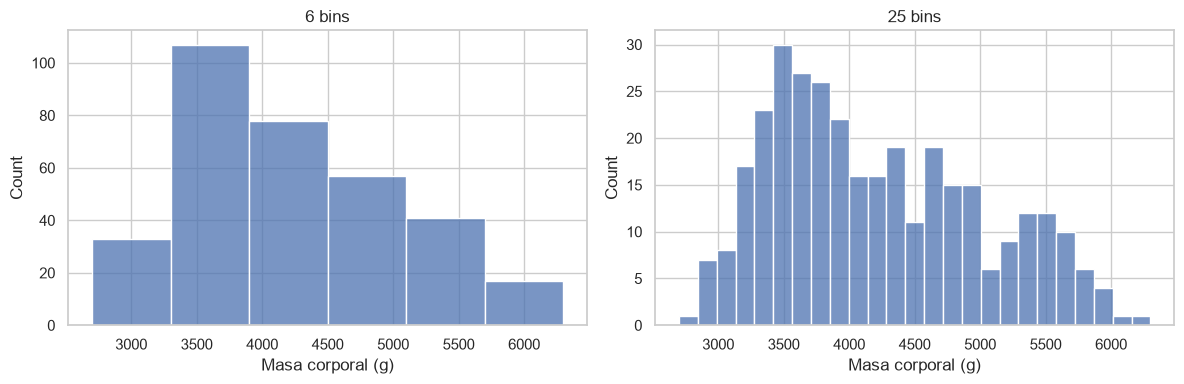

In [16]:
#3. Efecto de los bins 
#Construye dos histogramas de body_mass_g: uno con 6 bins y otro con 25 bins. Compara visualmente qué 
#detalles aparecen o se pierden al cambiar el número de intervalos. 

import matplotlib.pyplot as plt
import seaborn as sns

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con 6 bins
sns.histplot(data=penguins_clean, x="body_mass_g", bins=6, ax=axes[0])
axes[0].set_xlabel("Masa corporal (g)")
axes[0].set_title("6 bins")

# Histograma con 25 bins
sns.histplot(data=penguins_clean, x="body_mass_g", bins=25, ax=axes[1])
axes[1].set_xlabel("Masa corporal (g)")
axes[1].set_title("25 bins")

# Ajustar espacios
plt.tight_layout()
plt.show()


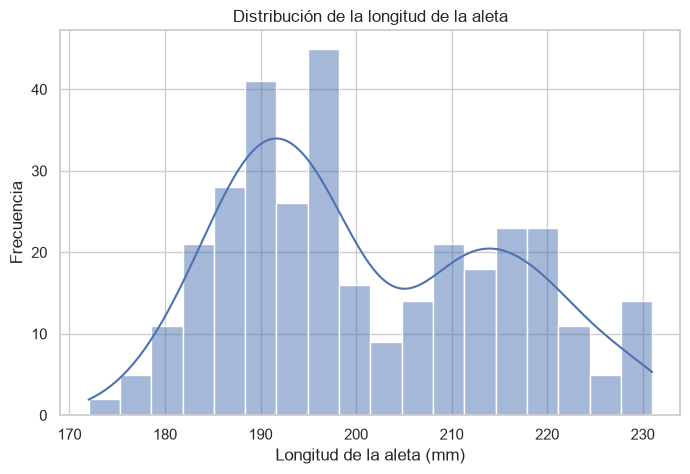

In [17]:
#4. Histograma con KDE 
#Crea un histograma de flipper_length_mm con 18 bins y activa kde=True. Describe brevemente si la 
#distribución parece formar uno o varios grupos. 

plt.figure(figsize=(8, 5))
sns.histplot(data=penguins_clean, x="flipper_length_mm", bins=18, kde=True)
plt.title("Distribución de la longitud de la aleta")
plt.xlabel("Longitud de la aleta (mm)")
plt.ylabel("Frecuencia")
plt.show()


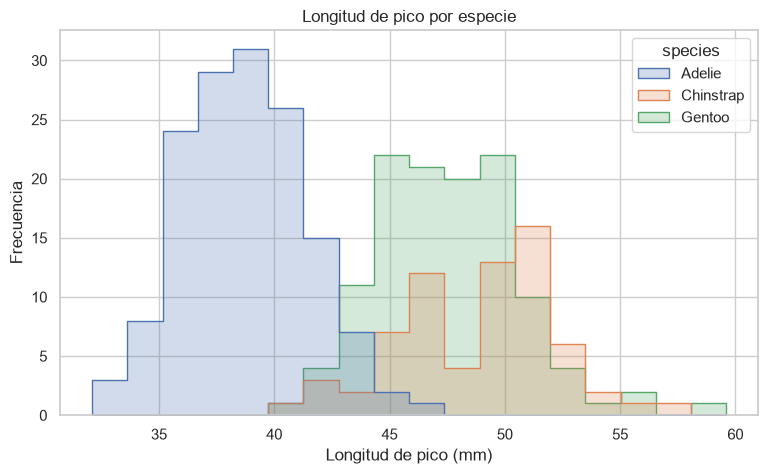

In [18]:
#5. Histograma agrupado 
#Crea un histplot de bill_length_mm usando species como hue. Configura la visualización para poder 
#comparar las tres especies y agrega un título. 

# 5. Histograma agrupado
# Crea un histplot de bill_length_mm usando species como hue. Configura la visualización para poder
# comparar las tres especies y agrega un título.

plt.figure(figsize=(9, 5))
sns.histplot(data=penguins_clean, x="bill_length_mm", hue="species", bins=18, element="step")
plt.title("Longitud de pico por especie")
plt.xlabel("Longitud de pico (mm)")
plt.ylabel("Frecuencia")
plt.show()


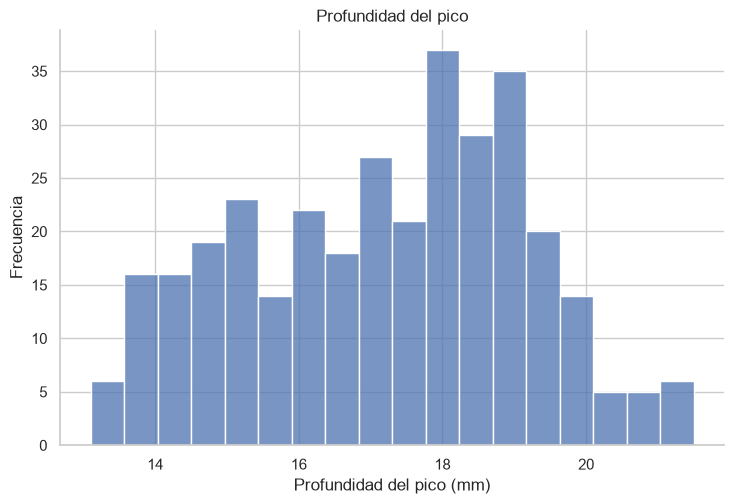

In [19]:
#6. Displot univariado 
#Usa displot para visualizar la distribución de bill_depth_mm. Personaliza el nombre del eje X y el título 
#general de la figura. 

sns.displot(data=penguins_clean, x="bill_depth_mm", bins=18, height=5, aspect=1.5)
plt.title("Profundidad del pico")
plt.xlabel("Profundidad del pico (mm)")
plt.ylabel("Frecuencia")
plt.show()

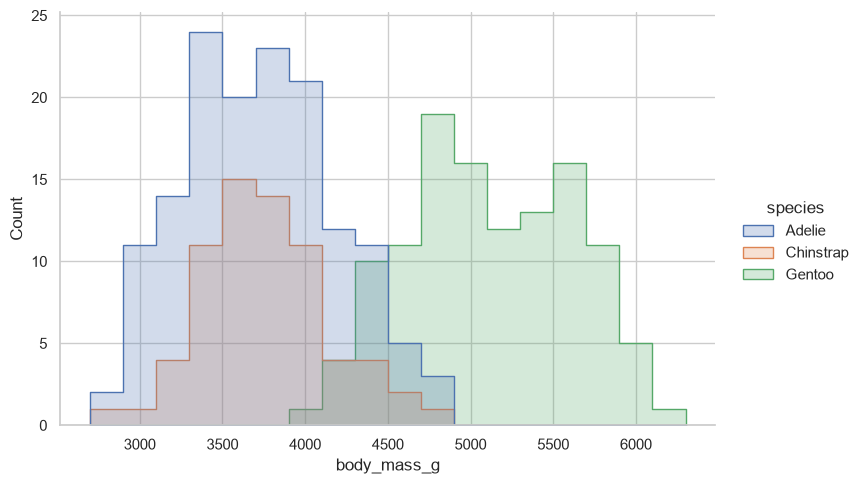

In [20]:
#7. Displot por especie 
#Crea un displot de body_mass_g diferenciado por species mediante hue. Indica qué especie tiende a 
#presentar las masas corporales más altas.

sns.displot(data=penguins_clean, x="body_mass_g", hue="species", bins=18, element="step", height=5, aspect=1.5)


In [21]:
penguins["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

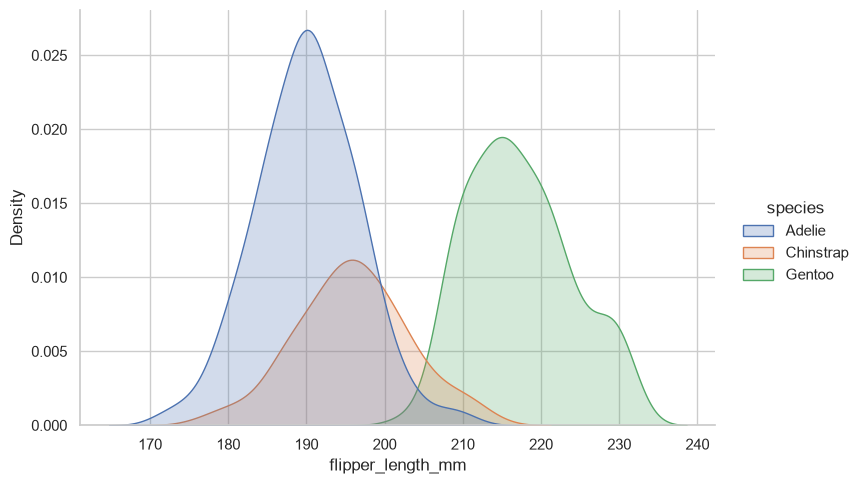

In [22]:
#8. Displot KDE 
#Crea un displot con kind="kde" para comparar la distribución de flipper_length_mm entre las tres especies 
#usando hue="species". 

sns.displot(data=penguins_clean, x="flipper_length_mm", hue="species", kind="kde", height=5, aspect=1.5, fill=True)


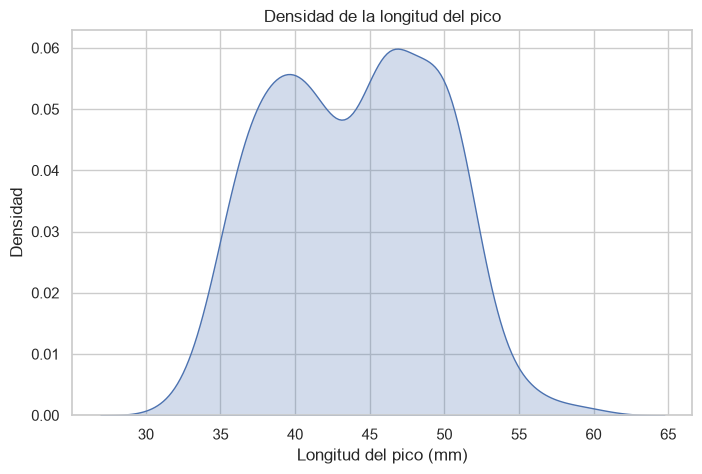

In [23]:
# 9. KDE básico
# Construye un kdeplot de bill_length_mm con el área rellena (fill=True). Añade título y etiqueta del eje X.

plt.figure(figsize=(8,5))
sns.kdeplot(data=penguins_clean, x="bill_length_mm", fill=True)
plt.title("Densidad de la longitud del pico")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Densidad")
plt.show()


<Axes: xlabel='island', ylabel='count'>

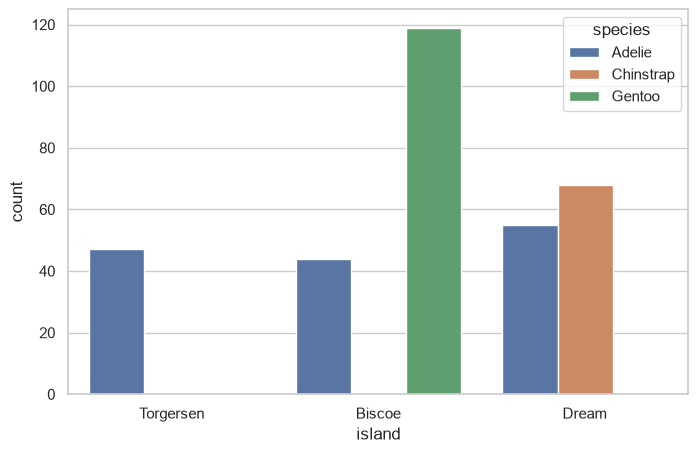

In [24]:
#12. Conteo por isla y especie 
#Crea un countplot con island en el eje X y species como hue. Describe qué especies aparecen en cada isla 
#según el gráfico. 

plt.figure(figsize=(8, 5))
sns.countplot(data=penguins_clean, x="island", hue="species")


<Axes: xlabel='species', ylabel='body_mass_g'>

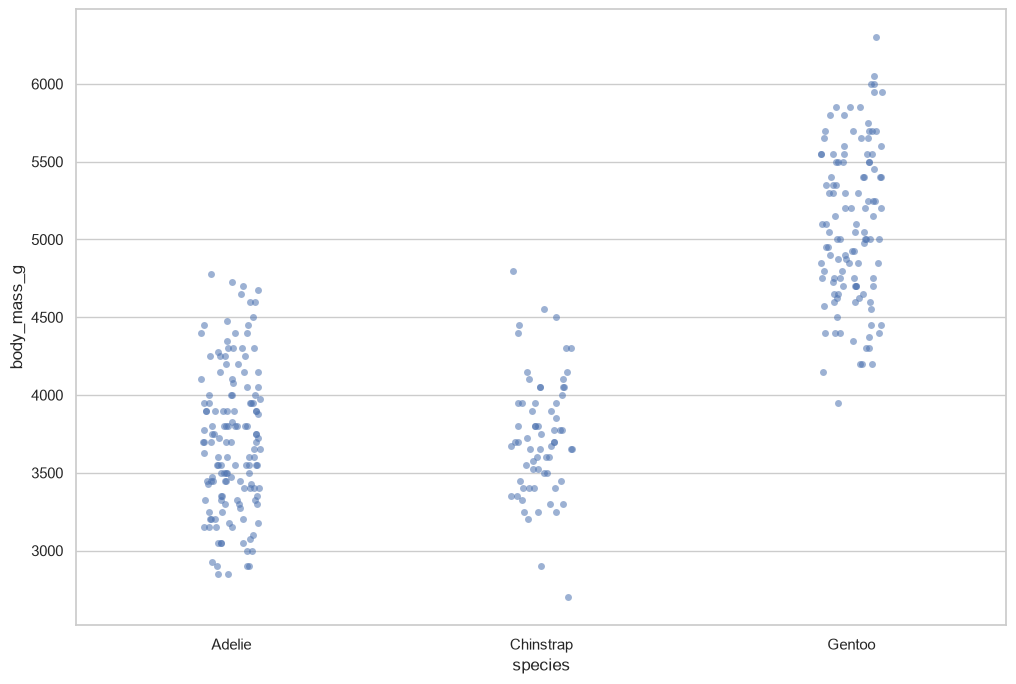

In [25]:
#13. Stripplot de masa corporal 
#Crea un stripplot con species en X y body_mass_g en Y. Usa transparencia para reducir la superposición de 
#puntos y describe qué especie parece ser más pesada. 

plt.figure(figsize=(12, 8))
sns.stripplot(data=penguins_clean, x="species", y="body_mass_g", alpha=0.55)


<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>

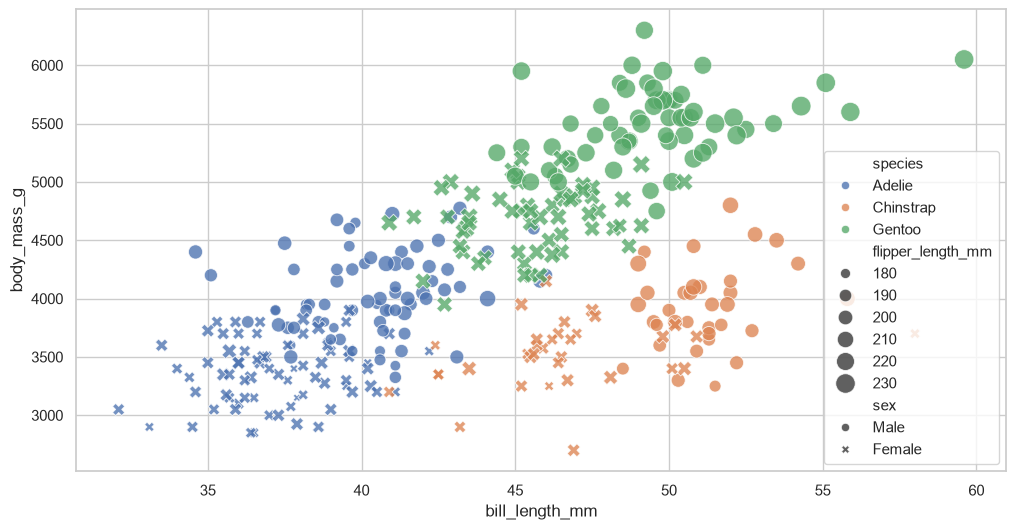

In [26]:
#18. Scatterplot multidimensional 
#Crea un scatterplot de bill_length_mm vs. body_mass_g usando species como hue, flipper_length_mm 
#como size y sex como style. Usa transparencia (alpha) para mejorar la lectura. 

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="body_mass_g",
    hue="species",
    size="flipper_length_mm",
    sizes=(30, 200),
    style="sex",
    alpha=0.78
)


In [ ]:






 

#9. KDE básico 
#Construye un kdeplot de bill_length_mm con el área rellena (fill=True). Añade título y etiqueta del eje X. 
#10. KDE comparativo 
#Crea un kdeplot de body_mass_g con hue="species" y fill=True. Explica brevemente qué grupos parecen 
#más separados. 
#B. Variables categóricas 
#11. Conteo por especie 
#Crea un countplot de species. Identifica cuál especie tiene más registros y cuál tiene menos. 
#12. Conteo por isla y especie 
#Crea un countplot con island en el eje X y species como hue. Describe qué especies aparecen en cada isla 
#según el gráfico. 

#14. Catplot tipo box 
#Crea un catplot con kind="box" para comparar body_mass_g entre las especies. Identifica visualmente si 
#existen valores atípicos y compara las medianas. 
#15. Catplot tipo violin 
#Crea un catplot con kind="violin" para comparar bill_length_mm entre las especies. Explica qué información 
#de la distribución se aprecia mejor aquí que en un boxplot. 
#C. Relaciones y análisis conjunto 
#16. Scatterplot del pico 
#Crea un scatterplot entre bill_length_mm y bill_depth_mm usando species como hue. Describe si las 
#especies forman grupos distinguibles. 
#17. Scatterplot de aleta y masa 
#Crea un scatterplot entre flipper_length_mm y body_mass_g usando species como hue. Describe si existe 
#una relación positiva, negativa o inexistente entre ambas variables. 

#19. Jointplot 
#Crea un jointplot de flipper_length_mm y body_mass_g con kind="scatter". Explica qué información 
#adicional proporcionan los gráficos marginales respecto a un scatterplot normal. 
#20. Pairplot final 
#Crea un pairplot con bill_length_mm, bill_depth_mm, flipper_length_mm y body_mass_g, usando species 
#como hue y corner=True. Escribe dos observaciones breves sobre las relaciones o separaciones que 
#encuentres.